# Sanity + Insight Test Suite (Shapley Attributions)

This notebook validates and extracts **robust, uncertainty-quantified findings** from token-level Shapley-value (SV) attributions for a multimodal LLM.

## What this notebook can / cannot conclude

**Can conclude (if tests pass):**
- Effects that remain after controlling for token length and passing permutation / null-model sanity checks.
- Whether effects are likely **denominator artifacts** (audio included in denominator) or **tokenization artifacts** (disappear at word-level).

**Cannot conclude:**
- Mechanistic/casual claims about internal model circuits.
- True token-token interactions unless you provide true Shapley interaction matrices (outer-product bridges are proxies).

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

# Ensure `experiments/analysis` is importable when running from repo root.
repo_root = Path.cwd().resolve()
analysis_dir = repo_root / "experiments" / "analysis"
if str(analysis_dir) not in sys.path:
    sys.path.insert(0, str(analysis_dir))

from sanity_suite_runner import run_suite  # noqa: E402

/home/mvishiu11/Desktop/AudioShap_WUT_Bachelor/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


## A) Data model + loaders

We build a canonical long-form table `df_tokens` where each row is a **single token** (text or audio).

### Adapters → canonical `df_tokens`
- `adapt_token_level_raw(...)` for token-per-row data
- `adapt_units_level_raw(...)` for message-per-row data with token arrays

Both produce a `df_tokens` with consistent columns and types.

## B) Core metrics + C) Subword-to-word merging

We compute metrics per `(sample_id, case, language)` using **current text**, **history text**, and **audio** where present.

Two important variants are computed:
- Token-level (as-is)
- Word-level (merged subwords → words), to catch tokenization artifacts

## D) Sanity checks + E/F) Comparison engine + G) Diagnostics + Report

The remaining cells implement:
- bridge hubness metrics + a null-model
- bootstrap CIs + effect sizes + BH correction
- required sanity tests (length confounds, denominator artifacts, permutation tests)
- automated ranked findings with caveat flags
- matplotlib-only diagnostic figures

token-level samples: (324, 36) word-level samples: (324, 36)

[Sanity] Denominator artifact
[Denominator artifact] Large +Δ means audio denominator suppresses retention_all.
case   n  mean_all  mean_textonly  mean_delta_textonly_minus_all  ci95_lo  ci95_hi  p_ttest_rel  effect_d_paired
 T2T 108  7.378494       7.378494                            0.0      0.0      0.0          NaN              NaN

[Sanity] Length control: case effects
  - Skipping shapley_entropy_text_current ~ token_count_text_current: only 1 case with data
  - shapley_entropy_all_current ~ token_count_all_current (n=324)
                     metric            term     coef     ci_lo    ci_hi        p   n  n_languages
shapley_entropy_all_current C(case)[T.SM2T] 0.007042 -0.062914 0.076999 0.843128 324            3
shapley_entropy_all_current  C(case)[T.T2T] 0.016384 -0.051135 0.083903 0.633394 324            3

[Sanity] POS permutation test (language-wise, current text)
language  pos  n_tokens  observed_mean_share  nu

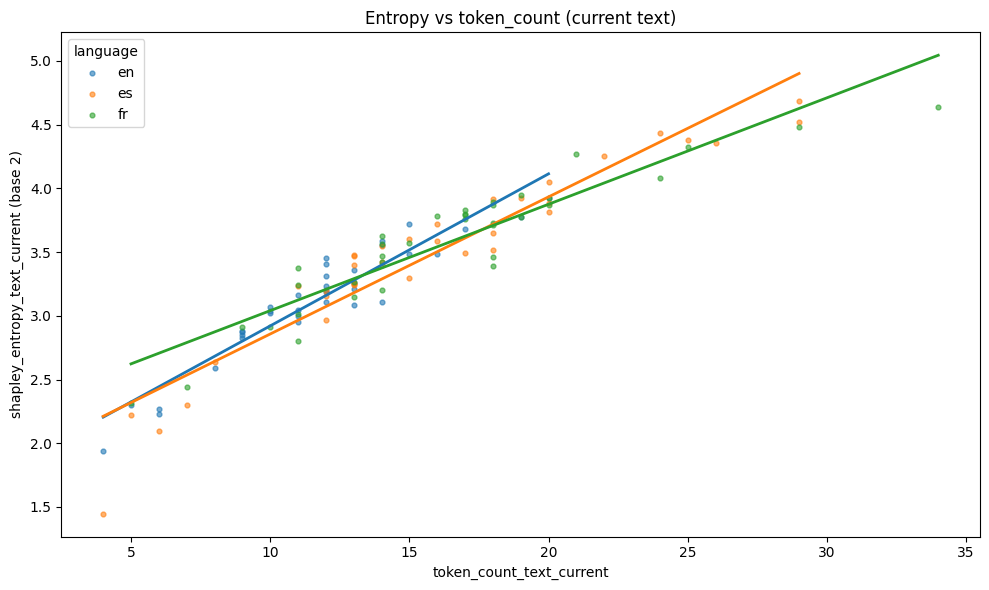

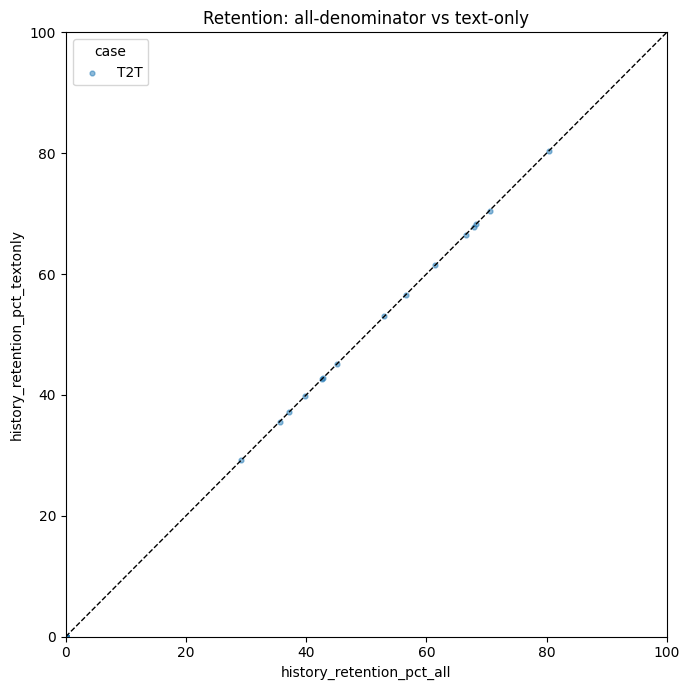

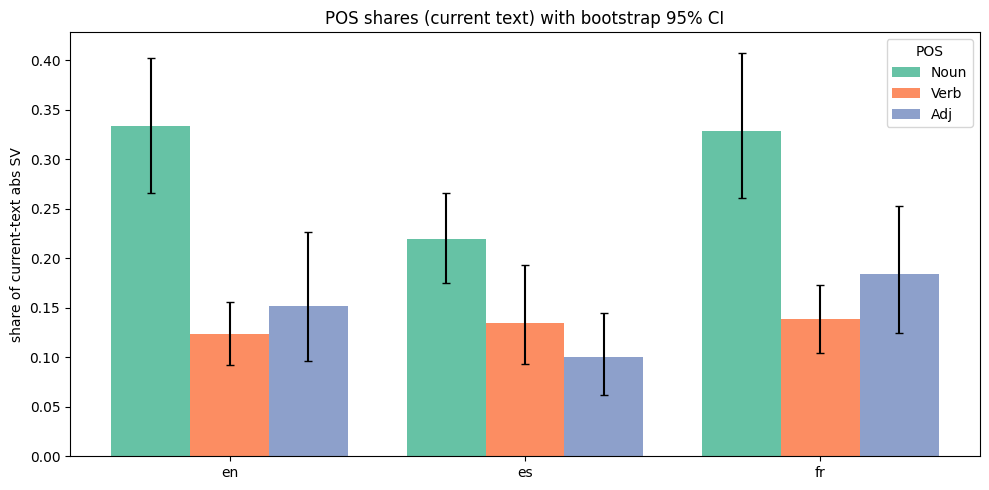

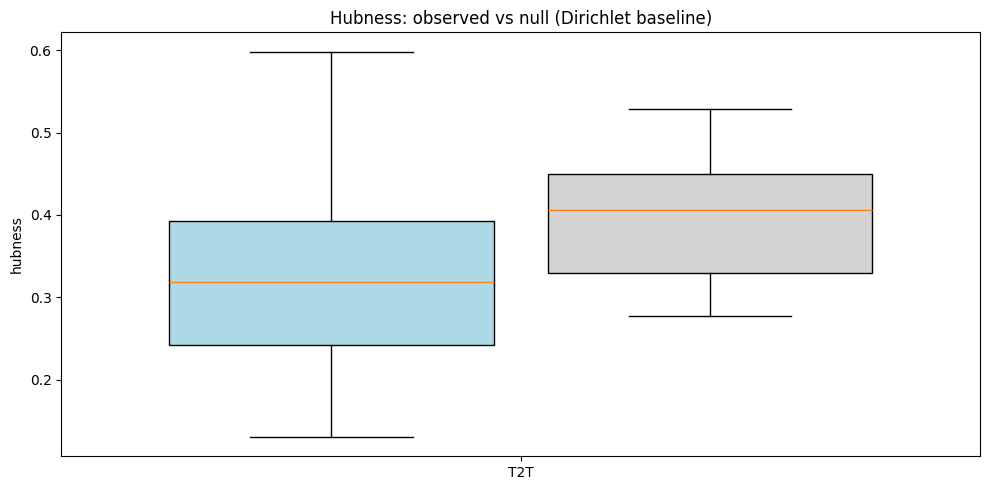

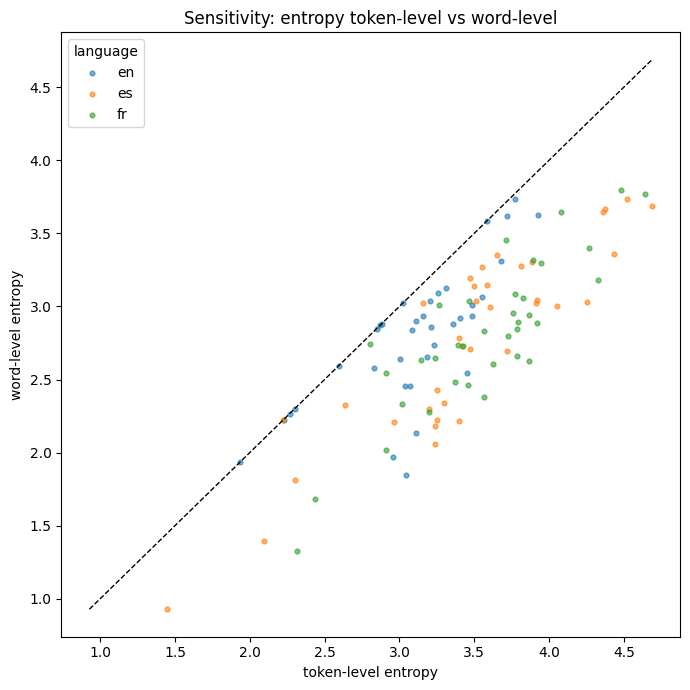

In [2]:
# Run when executing this notebook top-to-bottom
results = run_suite(save_figures=True)